<a href="https://colab.research.google.com/github/parviza9999/InterviewN/blob/main/LeNet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf


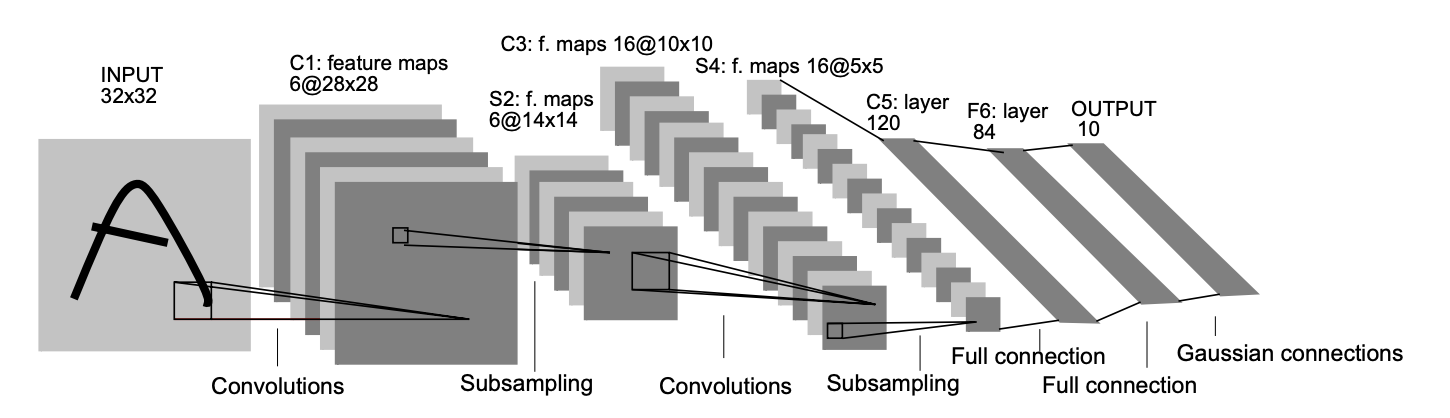

. Convolution Layer Output FormulaWhen you apply a convolution, the output size ($O$) depends on the input size ($I$), kernel size ($K$), padding ($P$), and stride ($S$).$$O = \left\lfloor \frac{I + 2P - K}{S} \right\rfloor + 1$$$I$ (Input Size): Height or width of the input feature map.$K$ (Kernel Size): The size of the filter window.$P$ (Padding): The number of pixels added to the border.$S$ (Stride): The step size of the filter window.$\lfloor \dots \rfloor$ (Floor): You round down the result to the nearest integer.Example: Input is $28 \times 28$, Kernel is $3 \times 3$, Padding is $1$, Stride is $1$:$$O = \left\lfloor \frac{28 + 2(1) - 3}{1} \right\rfloor + 1 = 28$$This confirms why padding=1 results in "same" output dimensions.2. Pooling Layer Output FormulaThe formula for Pooling (Max or Average) is very similar, though padding is usually $0$ in standard architectures.$$O = \left\lfloor \frac{I - K}{S} \right\rfloor + 1$$$I$ (Input Size): Height or width of the input map.$K$ (Kernel Size): The pooling window size.$S$ (Stride): How far the pooling window jumps.Example: Input is $26 \times 26$, Pooling Kernel is $2 \times 2$, Stride is $2$:$$O = \left\lfloor \frac{26 - 2}{2} \right\rfloor + 1 = 13$$This explains the spatial reduction often seen in CNN architectures.



The LeNet-5 architecture consists of 7 layers (excluding input):

Conv Layer 1: 6 filters ($5 \times 5$), followed by pooling.

Conv Layer 2: 16 filters ($5 \times 5$), followed by pooling.

Fully Connected Layers: 3 linear layers mapping to 10 output classes.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # C1: Convolutional layer (input: 1 channel, output: 6 filters, kernel: 5x5)
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        # S2: Subsampling (Average Pooling, kernel: 2x2, stride: 2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C3: Convolutional layer (6 -> 16 channels, kernel: 5x5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        # S4: Subsampling (Average Pooling)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C5: Fully connected layer
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # F6: Fully connected layer
        self.fc2 = nn.Linear(120, 84)
        # Output layer
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Activation: The original paper used Tanh; ReLU is modern standard
        x = F.tanh(self.conv1(x))
        x = self.pool1(x)
        x = F.tanh(self.conv2(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

# Test the model with dummy input (1 batch, 1 channel, 32x32 image)
model = LeNet5()
dummy_input = torch.randn(1, 1, 32, 32)
print(f"Output shape: {model(dummy_input).shape}")